In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from datetime import datetime
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

import torch
print(f"GPU: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import Dataset
import shutil
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM 
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments,DataCollatorForSeq2Seq
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

GPU: False
GPU: CPU


In [2]:
SAFN = pd.read_csv('/kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news/all-data.csv', 
                 encoding='latin-1',
                 header=None, 
                 names=['sentiment', 'title'])

SEntFiN = pd.read_csv('/kaggle/input/datasets/ankurzing/aspect-based-sentiment-analysis-for-financial-news/SEntFiN-v1.1.csv', 
                 encoding='latin-1')

SEntFiN = SEntFiN.drop('S No.', axis=1)
SEntFiN = SEntFiN.drop('Words', axis=1)


def extract_sentiment(text):
    if pd.isna(text):
        return None
    
    # neutral/positive/negative
    if 'neutral' in text.lower():
        return 'neutral'
    elif 'positive' in text.lower():
        return 'positive'
    elif 'negative' in text.lower():
        return 'negative'
    else:
        return None

SEntFiN['sentiment'] = SEntFiN['Decisions'].apply(extract_sentiment)
SEntFiN = SEntFiN.drop('Decisions', axis=1)

SEntFiN = SEntFiN.rename(columns={
    'Title': 'title'
})

SEntFiN = SEntFiN[['sentiment', 'title']]



def clean_and_prepare_data(df):
    df_clean = df.copy()
    
    df_clean = df_clean.dropna()
    df_clean = df_clean.reset_index(drop=True)
    
    if 'text' in df_clean.columns:
        df_clean['text'] = df_clean['text'].str.strip()
    
    # negative-0, neutral-1, positive-2
    label_encoder = LabelEncoder()
    
    if 'sentiment' in df_clean.columns:
        valid_labels = ['negative', 'neutral', 'positive']
        df_clean = df_clean[df_clean['sentiment'].isin(valid_labels)]

        df_clean['label'] = label_encoder.fit_transform(df_clean['sentiment'])
        
    else:
        print("No'sentiment'")
    
    print(f"Dataset Size: {df_clean.shape}")
    
    return df_clean
    
SAFN = clean_and_prepare_data(SAFN)
SEntFiN = clean_and_prepare_data(SEntFiN)

Dataset Size: (4846, 3)
Dataset Size: (10753, 3)


In [3]:
def simple_split_dataset(df, label_col='label', test_size=0.3, val_size=0.5, random_state=42):

    df_train, df_temp = train_test_split(
        df, 
        test_size=test_size,
        random_state=random_state,
        stratify=df[label_col]
    )

    df_val, df_test = train_test_split(
        df_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=df_temp[label_col]
    )
    
    print(f"Training set: {df_train.shape[0]} samples")
    print(f"Validation set: {df_val.shape[0]} samples")
    print(f"Test set: {df_test.shape[0]} samples")
    
    return df_train, df_val, df_test

SAFN_train, SAFN_val, SAFN_test = simple_split_dataset(SAFN, label_col='label', test_size=0.3, val_size=0.5, random_state=42)
SEntFiN_train, SEntFiN_val, SEntFiN_test = simple_split_dataset(SEntFiN, label_col='label', test_size=0.3, val_size=0.5, random_state=42)

Training set: 3392 samples
Validation set: 727 samples
Test set: 727 samples
Training set: 7527 samples
Validation set: 1613 samples
Test set: 1613 samples


In [4]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, average='macro'):

    results = {}

    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['Macro_Precision'] = precision_score(y_true, y_pred, average=average)
    results['Macro_Recall'] = recall_score(y_true, y_pred, average=average)
    results['Macro_F1'] = f1_score(y_true, y_pred, average=average)
    
    # Specificity
    cm = confusion_matrix(y_true, y_pred)
    specificity_scores = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_scores.append(specificity)
    results['Macro_Specificity'] = np.mean(specificity_scores)
    
    # AUC & AUPRC
    if y_pred_proba is not None:
        try:
            # One-vs-Rest ROC AUC
            results['Macro_AUC'] = roc_auc_score(y_true, y_pred_proba, average=average, multi_class='ovr')
            # One-vs-Rest AUPRC
            results['Macro_AUPRC'] = average_precision_score(y_true, y_pred_proba, average=average)
        except:
            results['Macro_AUC'] = None
            results['Macro_AUPRC'] = None
    
    return results

In [5]:
from sklearn.metrics import roc_curve, auc

def save_roc_data_for_plotting(model_name, dataset_split, y_true, y_pred_proba, 
                              csv_filepath='roc_plotting_data.csv'):
    
    if dataset_split.lower() != 'test':
        return
    
    try:
        n_classes = y_pred_proba.shape[1]

        if n_classes == 3:
            class_names = ['negative', 'neutral', 'positive']  # 0, 1, 2
        else:
            class_names = [f'Class_{i}' for i in range(n_classes)]
        
        data_to_save = []
        
        for class_idx in range(n_classes):
            # One-vs-Rest
            y_true_binary = (y_true == class_idx).astype(int)
            y_score = y_pred_proba[:, class_idx]
            
            # ROC
            fpr, tpr, _ = roc_curve(y_true_binary, y_score)
            roc_auc = auc(fpr, tpr)
            
            for fp_rate, tp_rate in zip(fpr, tpr):
                data_to_save.append({
                    'model': model_name,
                    'class_index': class_idx,
                    'class_name': class_names[class_idx],
                    'fpr': fp_rate,
                    'tpr': tp_rate,
                    'auc': roc_auc
                })

        df_roc = pd.DataFrame(data_to_save)

        if not os.path.exists(csv_filepath):
            df_roc.to_csv(csv_filepath, index=False)
        else:
            df_roc.to_csv(csv_filepath, mode='a', header=False, index=False)
        
        print(f"[ROC Data Saving] Model '{model_name}' ROC data saved to {csv_filepath}")
        print(f"  Classes: {class_names}")
        print(f"  Data points: {len(df_roc)} rows")
        
    except Exception as e:
        print(f"[Warning] Failed to save ROC data for model '{model_name}': {e}")

In [6]:
# def run_test_mode(train_data, val_data, test_data, test_size=30):
#     train_subset = train_data.head(test_size).copy()
#     val_subset = val_data.head(test_size).copy()
#     test_subset = test_data.head(test_size).copy()
    
#     return train_subset, val_subset, test_subset

# SAFN_train, SAFN_val, SAFN_test = run_test_mode(
#     SAFN_train, SAFN_val, SAFN_test, test_size=30
# )

# SEntFiN_train, SEntFiN_val, SEntFiN_test = run_test_mode(
#     SEntFiN_train, SEntFiN_val, SEntFiN_test, test_size=30
# )

In [7]:
def plot_all_models_roc_curves(all_models_roc_data, save_path='all_models_roc_curves.png'):

    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 8,
        'figure.titlesize': 12
    })
    
    models = all_models_roc_data['model'].unique()
    classes = all_models_roc_data['class_name'].unique()

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('#f3f2f9')
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.7, color='#b0b0b0', linestyle='--', linewidth=0.5)
    # for ax in axes:
    #     ax.set_facecolor('#ffffff')
    #     ax.set_axisbelow(True)
    #     ax.grid(True, alpha=0.3, color='#b0b0b0', linestyle='-', linewidth=0.5)
    #     ax.axhspan(0.8, 1.0, alpha=0.1, color='green')
    #     ax.axhspan(0.6, 0.8, alpha=0.1, color='orange')
    #     ax.axhspan(0.0, 0.6, alpha=0.1, color='red')


    model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for class_idx, (class_name, ax) in enumerate(zip(classes, axes)):
        ax.set_title(f'{class_name.capitalize()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5) # label='Random'

        for model_idx, model in enumerate(models):
            class_data = all_models_roc_data[
                (all_models_roc_data['model'] == model) & 
                (all_models_roc_data['class_name'] == class_name)
            ]
            
            if len(class_data) > 0:
                auc_value = class_data['auc'].iloc[0]
                color = model_colors[model_idx % len(model_colors)]
                ax.plot(class_data['fpr'], class_data['tpr'],
                       color=color,
                       linewidth=2,
                       label=f'{model} ({auc_value:.3f})')

        ax.legend(loc='lower right')

    # plt.suptitle('ROC Curves by Class', fontsize=12, fontweight='bold')

    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return save_path

In [8]:
def save_confusion_data(model_name, dataset_split, y_true, y_pred, csv_filepath='confusion_data.csv'):

    data = {
        'model': [model_name] * len(y_true),
        'dataset_split': [dataset_split] * len(y_true),
        'true_label': y_true,
        'pred_label': y_pred
    }
    
    df = pd.DataFrame(data)

    if os.path.exists(csv_filepath):
        existing_df = pd.read_csv(csv_filepath)
        df = pd.concat([existing_df, df], ignore_index=True)

    df.to_csv(csv_filepath, index=False)
    print(f"✅ Confusion data saved: {csv_filepath} (model: {model_name}, split: {dataset_split})")

## Qwen2
https://www.kaggle.com/models/qwen-lm/qwen2


In [9]:
# def qwen2(df_train, df_val, df_test, text_col='title', label_col='label',
#           num_labels=3, batch_size=1, epochs=1, model_save_path='models'):
    
#     import os
    
#     # prepare all data
#     all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

#     model_dirs = [
#         "/kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1",
#     ]
    
#     model_dir = None
#     for md in model_dirs:
#         if os.path.exists(md):
#             model_dir = md
#             print(f"found model: {md}")
#             break
    
#     if not model_dir:
#         print("❌ no Qwen2 model found")
#         return
    
#     temp_model_dir = f"./temp_qwen2_{os.getpid()}"
    
#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     shutil.copytree(model_dir, temp_model_dir)
#     print(f"copied model to: {temp_model_dir}")
    
#     # load from temp directory
#     tokenizer = AutoTokenizer.from_pretrained(temp_model_dir, trust_remote_code=True)
    
#     # padding token
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token
    
#     # CPU
#     device = torch.device("cpu")
#     print(f"device: {device}")
    
#     os.environ["CUDA_VISIBLE_DEVICES"] = ""  

#     model = AutoModelForCausalLM.from_pretrained(
#         temp_model_dir, 
#         trust_remote_code=True,
#         torch_dtype=torch.float32,
#     )

#     model = model.to(device)
#     model.config.pad_token_id = tokenizer.pad_token_id
#     model.config.use_cache = False
    
#     def tokenize_function(examples):
#         # tokenization
#         tokenized = tokenizer(
#             examples[text_col], 
#             truncation=True, 
#             max_length=32,  
#             padding='max_length',
#             return_tensors="pt"
#         )

#         tokenized['labels'] = torch.tensor(examples[label_col])
#         return tokenized
    
#     # prepare datasets
#     train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
#     val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
#     test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
#     all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
#     train_dataset = train_dataset.map(tokenize_function, batched=True)
#     val_dataset = val_dataset.map(tokenize_function, batched=True)
#     test_dataset = test_dataset.map(tokenize_function, batched=True)
#     all_dataset = all_dataset.map(tokenize_function, batched=True)
    
#     # PyTorch tensors
#     columns = ['input_ids', 'attention_mask', 'labels']
    
#     train_dataset.set_format(type='torch', columns=columns)
#     val_dataset.set_format(type='torch', columns=columns)
#     test_dataset.set_format(type='torch', columns=columns)
#     all_dataset.set_format(type='torch', columns=columns)
    
#     # data collator
#     data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#     class Qwen2Classifier(nn.Module):
#         def __init__(self, base_model, num_labels):
#             super().__init__()
#             self.qwen2 = base_model

#             for param in self.qwen2.parameters():
#                 param.requires_grad = False

#             hidden_size = self.qwen2.config.hidden_size
#             self.classifier = nn.Sequential(
#                 nn.Dropout(0.1),
#                 nn.Linear(hidden_size, 128), 
#                 nn.ReLU(),
#                 nn.Dropout(0.1),
#                 nn.Linear(128, num_labels)
#             )
            
#         def forward(self, input_ids, attention_mask=None, labels=None):
#             with torch.no_grad():
#                 outputs = self.qwen2(
#                     input_ids=input_ids,
#                     attention_mask=attention_mask,
#                     output_hidden_states=True
#                 )

#             hidden_states = outputs.hidden_states[-1]
#             last_token_hidden = hidden_states[:, -1, :]

#             logits = self.classifier(last_token_hidden)
            
#             loss = None
#             if labels is not None:
#                 loss_fct = nn.CrossEntropyLoss()
#                 loss = loss_fct(logits.view(-1, self.classifier[-1].out_features), labels.view(-1))
            
#             return (loss, logits) if loss is not None else logits
    
#     model_with_head = Qwen2Classifier(model, num_labels)
#     model_with_head = model_with_head.to(device)
    
#     training_args = TrainingArguments(
#         output_dir=f"./temp_train_{os.getpid()}",
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         num_train_epochs=epochs,
#         learning_rate=2e-5,
#         weight_decay=0.01,
#         logging_strategy="steps",
#         logging_steps=5,
#         save_strategy="no",
#         report_to="none",
#         remove_unused_columns=False,
#         eval_strategy="no",
#         load_best_model_at_end=False,
#         gradient_accumulation_steps=8,
#         dataloader_num_workers=0,
#         dataloader_pin_memory=False,
#         fp16=False,
#         disable_tqdm=False,
#     )
    
#     trainer = Trainer(
#         model=model_with_head,
#         args=training_args,
#         train_dataset=train_dataset,
#         data_collator=data_collator,
#     )
    

#     print("Training started...")
#     trainer.train()
#     print("✅ Training completed")

#     def batched_evaluate(model, dataset, device, batch_size=8, max_samples=None):

#         model.eval()

#         sample_count = len(dataset) if max_samples is None else min(len(dataset), max_samples)

#         all_labels = np.zeros(sample_count, dtype=np.int32)
#         all_preds = np.zeros(sample_count, dtype=np.int32)

#         with torch.no_grad():

#             test_item = dataset[0]
#             test_input_ids = test_item['input_ids'].unsqueeze(0).to(device)
#             test_attention_mask = test_item['attention_mask'].unsqueeze(0).to(device)
#             test_output = model(input_ids=test_input_ids, attention_mask=test_attention_mask)
#             test_logits = test_output[1] if isinstance(test_output, tuple) else test_output
#             num_classes = test_logits.shape[-1]
        
#         all_probs = np.zeros((sample_count, num_classes), dtype=np.float32)
        
#         print(f"Evaluating {sample_count} samples with batch_size={batch_size}...")

#         with torch.no_grad():
#             for start_idx in range(0, sample_count, batch_size):
#                 end_idx = min(start_idx + batch_size, sample_count)
#                 current_batch_size = end_idx - start_idx
                
#                 # 准备批量数据
#                 batch_input_ids = []
#                 batch_attention_mask = []
#                 batch_labels = []
                
#                 for i in range(start_idx, end_idx):
#                     item = dataset[i]
#                     batch_input_ids.append(item['input_ids'])
#                     batch_attention_mask.append(item['attention_mask'])
#                     batch_labels.append(item['labels'].item())

#                 input_ids_batch = torch.stack(batch_input_ids).to(device)
#                 attention_mask_batch = torch.stack(batch_attention_mask).to(device)

#                 outputs = model(
#                     input_ids=input_ids_batch,
#                     attention_mask=attention_mask_batch
#                 )

#                 logits = outputs[1] if isinstance(outputs, tuple) else outputs

#                 probs = torch.softmax(logits, dim=-1)
#                 preds = torch.argmax(probs, dim=-1)

#                 all_labels[start_idx:end_idx] = batch_labels
#                 all_preds[start_idx:end_idx] = preds.cpu().numpy()
#                 all_probs[start_idx:end_idx, :] = probs.cpu().numpy()

#                 if (start_idx // batch_size) % 5 == 0 or end_idx == sample_count:
#                     print(f"  Progress: {end_idx}/{sample_count} samples ({end_idx/sample_count*100:.1f}%)")
        
#         print(f"✅ Evaluation completed: {sample_count} samples")
#         return all_labels, all_preds, all_probs

#     eval_batch_size = 8  

#     print(f"Evaluating train set (batch_size={eval_batch_size})...")
#     y_train_true, y_train_pred, y_train_proba = batched_evaluate(
#         model_with_head, train_dataset, device, 
#         batch_size=eval_batch_size, max_samples=None
#     )
    
#     print(f"Evaluating validation set (batch_size={eval_batch_size})...")
#     y_val_true, y_val_pred, y_val_proba = batched_evaluate(
#         model_with_head, val_dataset, device, 
#         batch_size=eval_batch_size, max_samples=None
#     )
    
#     print(f"Evaluating test set (batch_size={eval_batch_size})...")
#     y_test_true, y_test_pred, y_test_proba = batched_evaluate(
#         model_with_head, test_dataset, device, 
#         batch_size=eval_batch_size, max_samples=None
#     )

#     results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
#     results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
#     results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)

#     print("train:")
#     for k, v in results_train.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("val:")
#     for k, v in results_val.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
#     print("test:")
#     for k, v in results_test.items():
#         print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

#     if not os.path.exists(model_save_path):
#         os.makedirs(model_save_path)
    
#     final_dir = os.path.join(model_save_path, "qwen2")
#     os.makedirs(final_dir, exist_ok=True)

#     torch.save(model_with_head.classifier.state_dict(), 
#                os.path.join(final_dir, "classifier.pth"))
    
#     # tokenizer
#     tokenizer.save_pretrained(final_dir)
    
#     import json
#     config = {
#         'model_type': 'qwen2-classifier',
#         'num_labels': num_labels,
#         'hidden_size': model.config.hidden_size,
#     }
#     with open(os.path.join(final_dir, "config.json"), 'w') as f:
#         json.dump(config, f, indent=2)
    
#     print(f"✅ model saved: {final_dir}")

#     save_roc_data_for_plotting(
#         model_name="qwen2",
#         dataset_split='test', 
#         y_true=y_test_true,
#         y_pred_proba=y_test_proba,  
#         csv_filepath=os.path.join(model_save_path, 'all_models_roc_data.csv')
#     )

#     if os.path.exists(temp_model_dir):
#         shutil.rmtree(temp_model_dir)
    
#     for temp_dir in [f"./temp_train_{os.getpid()}"]:
#         if os.path.exists(temp_dir):
#             shutil.rmtree(temp_dir)
    
#     print("✅ All steps completed successfully")


# print("="*40)
# print('Dataset: SAFN')
# qwen2(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
#       num_labels=3, batch_size=1, epochs=1, model_save_path='SAFN')

In [10]:
def qwen2(df_train, df_val, df_test, text_col='title', label_col='label',
          num_labels=3, batch_size=1, epochs=1, model_save_path='models'):
    
    import os
    
    # prepare all data
    all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

    model_dirs = [
        "/kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1",
    ]
    
    model_dir = None
    for md in model_dirs:
        if os.path.exists(md):
            model_dir = md
            print(f"found model: {md}")
            break
    
    if not model_dir:
        print("❌ no Qwen2 model found")
        return
    
    temp_model_dir = f"./temp_qwen2_{os.getpid()}"
    
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    shutil.copytree(model_dir, temp_model_dir)
    print(f"copied model to: {temp_model_dir}")
    
    # load from temp directory
    tokenizer = AutoTokenizer.from_pretrained(temp_model_dir, trust_remote_code=True)
    
    # padding token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    # CPU
    device = torch.device("cpu")
    print(f"device: {device}")
    
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  

    model = AutoModelForCausalLM.from_pretrained(
        temp_model_dir, 
        trust_remote_code=True,
        torch_dtype=torch.float32,
    )

    model = model.to(device)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    
    def tokenize_function(examples):
        # tokenization
        tokenized = tokenizer(
            examples[text_col], 
            truncation=True, 
            max_length=32,  
            padding='max_length',
            return_tensors="pt"
        )

        tokenized['labels'] = torch.tensor(examples[label_col])
        return tokenized
    
    # prepare datasets
    train_dataset = Dataset.from_pandas(df_train[[text_col, label_col]])
    val_dataset = Dataset.from_pandas(df_val[[text_col, label_col]])
    test_dataset = Dataset.from_pandas(df_test[[text_col, label_col]])
    all_dataset = Dataset.from_pandas(all_df[[text_col, label_col]])
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    all_dataset = all_dataset.map(tokenize_function, batched=True)
    
    # PyTorch tensors
    columns = ['input_ids', 'attention_mask', 'labels']
    
    train_dataset.set_format(type='torch', columns=columns)
    val_dataset.set_format(type='torch', columns=columns)
    test_dataset.set_format(type='torch', columns=columns)
    all_dataset.set_format(type='torch', columns=columns)
    
    # data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    class Qwen2Classifier(nn.Module):
        def __init__(self, base_model, num_labels):
            super().__init__()
            self.qwen2 = base_model

            for param in self.qwen2.parameters():
                param.requires_grad = False

            hidden_size = self.qwen2.config.hidden_size
            self.classifier = nn.Sequential(
                nn.Dropout(0.1),
                nn.Linear(hidden_size, 128), 
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(128, num_labels)
            )
            
        def forward(self, input_ids, attention_mask=None, labels=None):
            with torch.no_grad():
                outputs = self.qwen2(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_hidden_states=True
                )

            hidden_states = outputs.hidden_states[-1]
            last_token_hidden = hidden_states[:, -1, :]

            logits = self.classifier(last_token_hidden)
            
            loss = None
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.classifier[-1].out_features), labels.view(-1))
            
            return (loss, logits) if loss is not None else logits
    
    # ==================== train ====================
    print("="*50)
    print("Stage 1: Initial training (train set only)")
    print("="*50)
    
    model_with_head = Qwen2Classifier(model, num_labels)
    model_with_head = model_with_head.to(device)
    
    training_args = TrainingArguments(
        output_dir=f"./temp_train_{os.getpid()}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=5,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        eval_strategy="no",
        load_best_model_at_end=False,
        gradient_accumulation_steps=8,
        dataloader_num_workers=0,
        dataloader_pin_memory=False,
        fp16=False,
        disable_tqdm=False,
    )
    
    trainer = Trainer(
        model=model_with_head,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=data_collator,
    )
    
    print("Training started...")
    trainer.train()
    print("✅ Initial training completed")

    
    def batched_evaluate(model, dataset, device, batch_size=8, max_samples=None):

        model.eval()
        
        sample_count = len(dataset) if max_samples is None else min(len(dataset), max_samples)

        all_labels = np.zeros(sample_count, dtype=np.int32)
        all_preds = np.zeros(sample_count, dtype=np.int32)

        with torch.no_grad():
            test_item = dataset[0]
            test_input_ids = test_item['input_ids'].unsqueeze(0).to(device)
            test_attention_mask = test_item['attention_mask'].unsqueeze(0).to(device)
            test_output = model(input_ids=test_input_ids, attention_mask=test_attention_mask)
            test_logits = test_output[1] if isinstance(test_output, tuple) else test_output
            num_classes = test_logits.shape[-1]
        
        all_probs = np.zeros((sample_count, num_classes), dtype=np.float32)
        
        print(f"Evaluating {sample_count} samples with batch_size={batch_size}...")

        with torch.no_grad():
            for start_idx in range(0, sample_count, batch_size):
                end_idx = min(start_idx + batch_size, sample_count)
                current_batch_size = end_idx - start_idx

                batch_input_ids = []
                batch_attention_mask = []
                batch_labels = []
                
                for i in range(start_idx, end_idx):
                    item = dataset[i]
                    batch_input_ids.append(item['input_ids'])
                    batch_attention_mask.append(item['attention_mask'])
                    batch_labels.append(item['labels'].item())

                input_ids_batch = torch.stack(batch_input_ids).to(device)
                attention_mask_batch = torch.stack(batch_attention_mask).to(device)

                outputs = model(
                    input_ids=input_ids_batch,
                    attention_mask=attention_mask_batch
                )

                logits = outputs[1] if isinstance(outputs, tuple) else outputs

                probs = torch.softmax(logits, dim=-1)
                preds = torch.argmax(probs, dim=-1)

                all_labels[start_idx:end_idx] = batch_labels
                all_preds[start_idx:end_idx] = preds.cpu().numpy()
                all_probs[start_idx:end_idx, :] = probs.cpu().numpy()

                if (start_idx // batch_size) % 5 == 0 or end_idx == sample_count:
                    print(f"  Progress: {end_idx}/{sample_count} samples ({end_idx/sample_count*100:.1f}%)")
        
        print(f"✅ Evaluation completed: {sample_count} samples")
        return all_labels, all_preds, all_probs
    
    eval_batch_size = 8 

    print(f"Evaluating train set (batch_size={eval_batch_size})...")
    y_train_true, y_train_pred, y_train_proba = batched_evaluate(
        model_with_head, train_dataset, device, 
        batch_size=eval_batch_size, max_samples=None
    )
    
    print(f"Evaluating validation set (batch_size={eval_batch_size})...")
    y_val_true, y_val_pred, y_val_proba = batched_evaluate(
        model_with_head, val_dataset, device, 
        batch_size=eval_batch_size, max_samples=None
    )
    
    print(f"Evaluating test set (batch_size={eval_batch_size})...")
    y_test_true, y_test_pred, y_test_proba = batched_evaluate(
        model_with_head, test_dataset, device, 
        batch_size=eval_batch_size, max_samples=None
    )
    
    results_train = evaluate_model(y_train_true, y_train_pred, y_train_proba)
    results_val = evaluate_model(y_val_true, y_val_pred, y_val_proba)
    results_test = evaluate_model(y_test_true, y_test_pred, y_test_proba)

    print("train:")
    for k, v in results_train.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("val:")
    for k, v in results_val.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    print("test:")
    for k, v in results_test.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, (int, float)) else f"  {k}: {v}")
    
    
    # # ==================== full data ====================
    # print("\n" + "="*50)
    # print("Stage 2: Full data training (train + val + test)")
    # print("="*50)

    # print("Creating new model for full data training...")
    # model_final = AutoModelForCausalLM.from_pretrained(
    #     temp_model_dir, 
    #     trust_remote_code=True,
    #     torch_dtype=torch.float32,
    # )
    # model_final = model_final.to(device)
    # model_final.config.pad_token_id = tokenizer.pad_token_id
    # model_final.config.use_cache = False

    # model_final_with_head = Qwen2Classifier(model_final, num_labels)
    # model_final_with_head = model_final_with_head.to(device)

    # training_args_final = TrainingArguments(
    #     output_dir=f"./temp_final_{os.getpid()}",
    #     per_device_train_batch_size=batch_size,
    #     num_train_epochs=epochs,
    #     learning_rate=1e-5,
    #     weight_decay=0.01,
    #     logging_strategy="steps",
    #     logging_steps=5,
    #     save_strategy="no",
    #     report_to="none",
    #     remove_unused_columns=False,
    #     eval_strategy="no",
    #     load_best_model_at_end=False,
    #     gradient_accumulation_steps=16, 
    #     dataloader_num_workers=0,
    #     dataloader_pin_memory=False,
    #     fp16=False,
    #     disable_tqdm=False,
    # )
    
    # trainer_final = Trainer(
    #     model=model_final_with_head,
    #     args=training_args_final,
    #     train_dataset=all_dataset,  # full data
    #     data_collator=data_collator,
    # )
    
    # # final
    # print("Full data training started...")
    # trainer_final.train()
    # print("✅ Full data training completed")

    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    final_dir = os.path.join(model_save_path, "qwen2")
    os.makedirs(final_dir, exist_ok=True)

    # torch.save(model_final_with_head.classifier.state_dict(), 
    #            os.path.join(final_dir, "classifier.pth"))
    torch.save(model_with_head.classifier.state_dict(), 
               os.path.join(final_dir, "classifier.pth"))

    tokenizer.save_pretrained(final_dir)
    
    import json
    config = {
        'model_type': 'qwen2-classifier',
        'num_labels': num_labels,
        'hidden_size': model.config.hidden_size, #model_final.config.hidden_size,
        'training_info': {
            'initial_epochs': epochs,
            'full_data_epochs': epochs,
            'learning_rate_initial': 2e-5,
            'learning_rate_final': 1e-5,
            'trained_on': 'train_set_only' #'full_data'
        }
    }
    with open(os.path.join(final_dir, "config.json"), 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f"✅ Full data model saved: {final_dir}")
    print(f"   Model trained on: {len(all_df)} samples (train + val + test)")

    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
    
    for temp_dir in [f"./temp_train_{os.getpid()}", f"./temp_final_{os.getpid()}"]:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
    
    print("✅ All steps completed successfully")
    
    save_roc_data_for_plotting(
        model_name="qwen2",
        dataset_split='test', 
        y_true=y_test_true,
        y_pred_proba=y_test_proba,  
        csv_filepath=os.path.join(model_save_path, 'all_models_roc_data.csv')
    )

    save_confusion_data(
    model_name="qwen2",
    dataset_split='test', 
    y_true=y_test_true,
    y_pred=y_test_pred,
    csv_filepath=f'{model_save_path}/all_models_confusion_data.csv' 
    )

In [11]:
print('Dataset: SAFN')
qwen2(SAFN_train, SAFN_val, SAFN_test, text_col='title', label_col='label',
      num_labels=3, batch_size=1, epochs=1, model_save_path='SAFN')

Dataset: SAFN
found model: /kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1
copied model to: ./temp_qwen2_17


`torch_dtype` is deprecated! Use `dtype` instead!


device: cpu


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Map:   0%|          | 0/3392 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/727 [00:00<?, ? examples/s]

Map:   0%|          | 0/4846 [00:00<?, ? examples/s]

Stage 1: Initial training (train set only)
Training started...


Step,Training Loss
5,2.064140
10,1.793128
15,1.611316
20,1.345843
25,1.341747
30,1.044405
35,1.092974
40,1.161336
45,1.233474
50,1.057162


✅ Initial training completed
Evaluating train set (batch_size=8)...
Evaluating 3392 samples with batch_size=8...
  Progress: 8/3392 samples (0.2%)
  Progress: 48/3392 samples (1.4%)
  Progress: 88/3392 samples (2.6%)
  Progress: 128/3392 samples (3.8%)
  Progress: 168/3392 samples (5.0%)
  Progress: 208/3392 samples (6.1%)
  Progress: 248/3392 samples (7.3%)
  Progress: 288/3392 samples (8.5%)
  Progress: 328/3392 samples (9.7%)
  Progress: 368/3392 samples (10.8%)
  Progress: 408/3392 samples (12.0%)
  Progress: 448/3392 samples (13.2%)
  Progress: 488/3392 samples (14.4%)
  Progress: 528/3392 samples (15.6%)
  Progress: 568/3392 samples (16.7%)
  Progress: 608/3392 samples (17.9%)
  Progress: 648/3392 samples (19.1%)
  Progress: 688/3392 samples (20.3%)
  Progress: 728/3392 samples (21.5%)
  Progress: 768/3392 samples (22.6%)
  Progress: 808/3392 samples (23.8%)
  Progress: 848/3392 samples (25.0%)
  Progress: 888/3392 samples (26.2%)
  Progress: 928/3392 samples (27.4%)
  Progress: 

In [12]:
source_path = '/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN/all_models_roc_data.csv'
target_path = '/kaggle/working/SAFN/all_models_roc_data.csv'

df_source = pd.read_csv(source_path)
df_target = pd.read_csv(target_path)

df_combined = pd.concat([df_source, df_target], ignore_index=True)
df_combined.to_csv(target_path, index=False)

print(df_combined.head())
print(df_combined.tail())

       model  class_index class_name       fpr       tpr       auc
0  mlp_TFIDF            0   negative  0.000000  0.000000  0.887034
1  mlp_TFIDF            0   negative  0.000000  0.010989  0.887034
2  mlp_TFIDF            0   negative  0.000000  0.120879  0.887034
3  mlp_TFIDF            0   negative  0.001572  0.120879  0.887034
4  mlp_TFIDF            0   negative  0.001572  0.219780  0.887034
      model  class_index class_name       fpr       tpr       auc
2937  qwen2            2   positive  0.988528  0.990196  0.558364
2938  qwen2            2   positive  0.988528  0.995098  0.558364
2939  qwen2            2   positive  0.994264  0.995098  0.558364
2940  qwen2            2   positive  0.994264  1.000000  0.558364
2941  qwen2            2   positive  1.000000  1.000000  0.558364


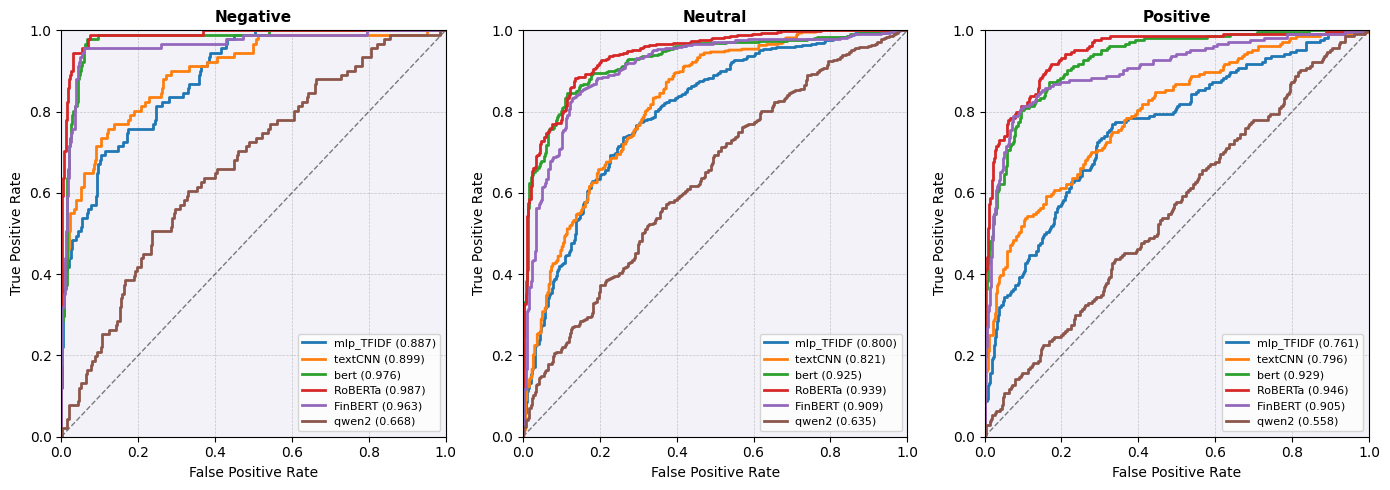

'SAFN_roc_curves.png'

In [13]:
SAFN_res = pd.read_csv('/kaggle/working/SAFN/all_models_roc_data.csv')
plot_all_models_roc_curves(SAFN_res, 'SAFN_roc_curves.png')

In [14]:
print('Dataset: SEntFiN')
qwen2(SEntFiN_train, SEntFiN_val, SEntFiN_test, text_col='title', label_col='label',
      num_labels=3, batch_size=1, epochs=1, model_save_path='SEntFiN')

Dataset: SEntFiN
found model: /kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1
copied model to: ./temp_qwen2_17
device: cpu


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Map:   0%|          | 0/7527 [00:00<?, ? examples/s]

Map:   0%|          | 0/1613 [00:00<?, ? examples/s]

Map:   0%|          | 0/1613 [00:00<?, ? examples/s]

Map:   0%|          | 0/10753 [00:00<?, ? examples/s]

Stage 1: Initial training (train set only)
Training started...


Step,Training Loss
5,1.250920
10,1.019099
15,1.294521
20,1.335530
25,1.353974
30,1.132930
35,1.231798
40,1.382050
45,1.513888
50,1.160014


✅ Initial training completed
Evaluating train set (batch_size=8)...
Evaluating 7527 samples with batch_size=8...
  Progress: 8/7527 samples (0.1%)
  Progress: 48/7527 samples (0.6%)
  Progress: 88/7527 samples (1.2%)
  Progress: 128/7527 samples (1.7%)
  Progress: 168/7527 samples (2.2%)
  Progress: 208/7527 samples (2.8%)
  Progress: 248/7527 samples (3.3%)
  Progress: 288/7527 samples (3.8%)
  Progress: 328/7527 samples (4.4%)
  Progress: 368/7527 samples (4.9%)
  Progress: 408/7527 samples (5.4%)
  Progress: 448/7527 samples (6.0%)
  Progress: 488/7527 samples (6.5%)
  Progress: 528/7527 samples (7.0%)
  Progress: 568/7527 samples (7.5%)
  Progress: 608/7527 samples (8.1%)
  Progress: 648/7527 samples (8.6%)
  Progress: 688/7527 samples (9.1%)
  Progress: 728/7527 samples (9.7%)
  Progress: 768/7527 samples (10.2%)
  Progress: 808/7527 samples (10.7%)
  Progress: 848/7527 samples (11.3%)
  Progress: 888/7527 samples (11.8%)
  Progress: 928/7527 samples (12.3%)
  Progress: 968/7527 s

In [15]:
source_path = '/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN/all_models_roc_data.csv'
target_path = '/kaggle/working/SEntFiN/all_models_roc_data.csv'

df_source = pd.read_csv(source_path)
df_target = pd.read_csv(target_path)

df_combined = pd.concat([df_source, df_target], ignore_index=True)
df_combined.to_csv(target_path, index=False)

print(df_combined.head())
print(df_combined.tail())

       model  class_index class_name       fpr       tpr       auc
0  mlp_TFIDF            0   negative  0.000000  0.000000  0.867738
1  mlp_TFIDF            0   negative  0.000000  0.002457  0.867738
2  mlp_TFIDF            0   negative  0.000000  0.085995  0.867738
3  mlp_TFIDF            0   negative  0.000829  0.085995  0.867738
4  mlp_TFIDF            0   negative  0.000829  0.176904  0.867738
      model  class_index class_name       fpr       tpr       auc
7174  qwen2            2   positive  0.983441  0.996198  0.611483
7175  qwen2            2   positive  0.983441  0.998099  0.611483
7176  qwen2            2   positive  0.993560  0.998099  0.611483
7177  qwen2            2   positive  0.993560  1.000000  0.611483
7178  qwen2            2   positive  1.000000  1.000000  0.611483


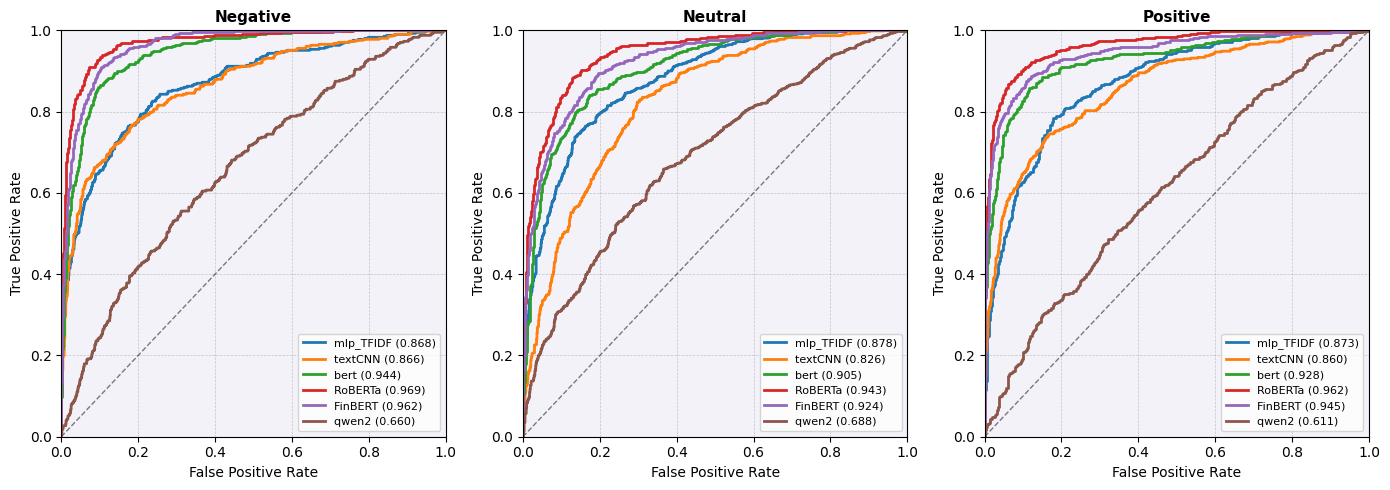

'SEntFiN_roc_curves.png'

In [16]:
SEntFiN_res = pd.read_csv('/kaggle/working/SEntFiN/all_models_roc_data.csv')
plot_all_models_roc_curves(SEntFiN_res, 'SEntFiN_roc_curves.png')

Models found: ['qwen2']

Plotting: qwen2


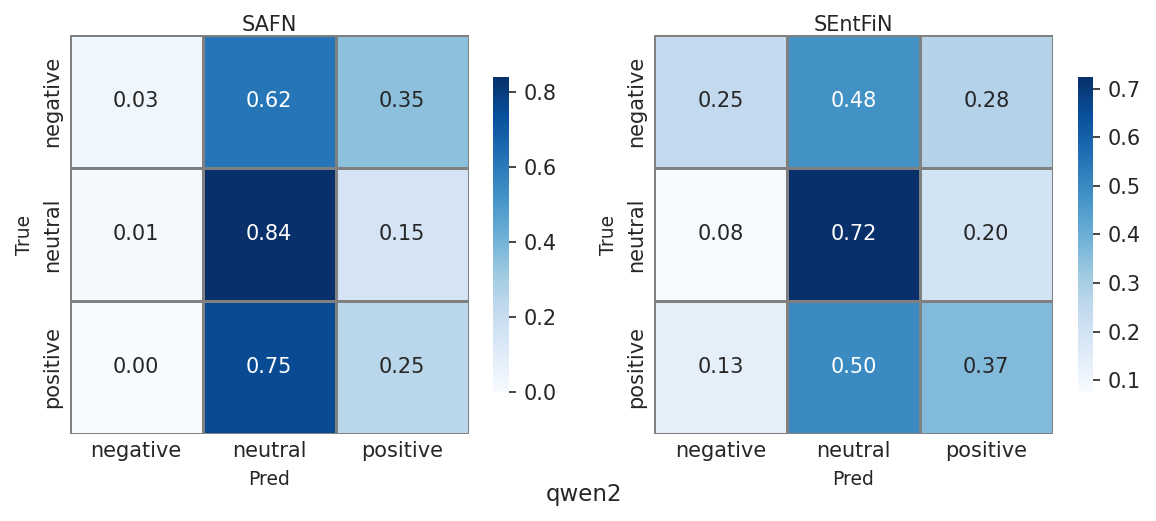


All confusion matrices plotted successfully.


In [17]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

def plot_model_confusion(model_name, data_paths, dataset_names, label_mapping=None):
    """
    More compact confusion matrix plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))  # Slightly shorter
    
    for idx, (data_path, dataset_name) in enumerate(zip(data_paths, dataset_names)):
        if not os.path.exists(data_path):
            axes[idx].axis('off')
            continue
            
        df = pd.read_csv(data_path)
        model_data = df[df['model'] == model_name]
        
        if len(model_data) == 0:
            axes[idx].axis('off')
            continue
        
        labels = sorted(set(model_data['true_label'].unique()) | 
                       set(model_data['pred_label'].unique()))
        
        cm = confusion_matrix(model_data['true_label'], 
                             model_data['pred_label'], 
                             labels=labels)
        cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm_normalized = np.nan_to_num(cm_normalized, nan=0.0)
        
        if label_mapping is not None:
            tick_labels = [label_mapping.get(label, str(label)) for label in labels]
        else:
            tick_labels = [str(label) for label in labels]
        
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt=".2f", 
                   cmap="Blues",
                   cbar=True,
                   square=True,
                   linewidths=0.5,
                   linecolor='gray',
                   ax=axes[idx],
                   xticklabels=tick_labels,
                   yticklabels=tick_labels,
                   cbar_kws={"shrink": 0.7})  # Smaller colorbar
        
        axes[idx].set_xlabel('Pred', fontsize=9)
        axes[idx].set_ylabel('True', fontsize=9)
        axes[idx].set_title(dataset_name, fontsize=10, pad=0.5)  # Minimal padding
        
        axes[idx].tick_params(axis='both', length=0)
    
    fig.suptitle(f"{model_name}", fontsize=11, y=0.02)  # Even tighter
    plt.tight_layout(pad=1.5)  # Minimal padding
    return fig

# Configuration
data_paths = [
    '/kaggle/working/SAFN/all_models_confusion_data.csv',
    '/kaggle/working/SEntFiN/all_models_confusion_data.csv'
]

dataset_names = ['SAFN', 'SEntFiN']

# Label mapping
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Find all models
all_models = set()
for path in data_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        all_models.update(df['model'].unique())

print(f"Models found: {list(all_models)}")

# Plot for each model
for model in all_models:
    print(f"\nPlotting: {model}")
    fig = plot_model_confusion(model, data_paths, dataset_names, label_mapping)
    
    if fig is not None:
        save_path = f'/kaggle/working/{model}_confusion_matrices.png'
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)

print("\nAll confusion matrices plotted successfully.")

Models found: ['FinBERT', 'mlp_TFIDF', 'bert', 'textCNN', 'RoBERTa']

Plotting: FinBERT


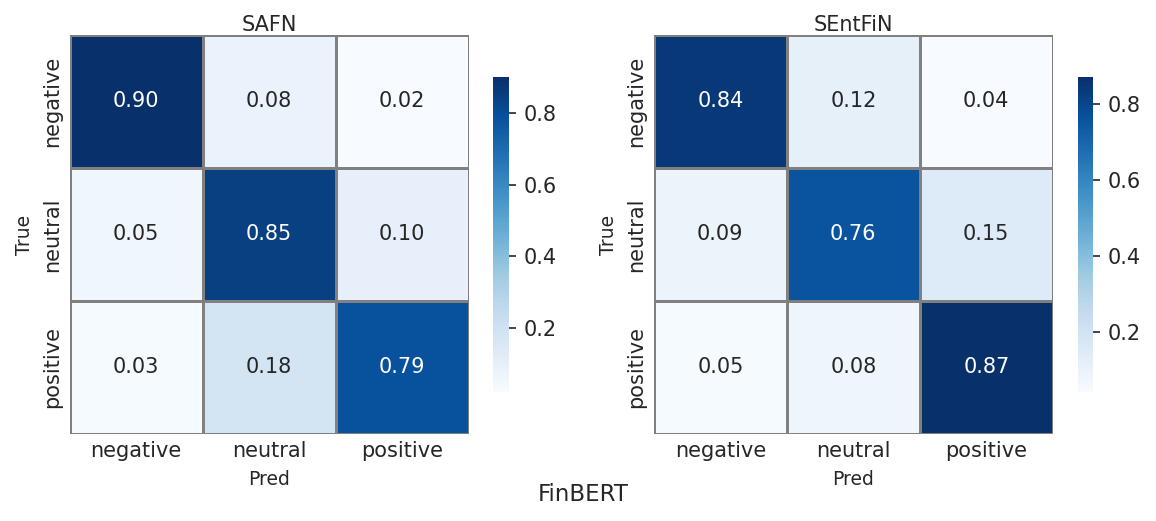


Plotting: mlp_TFIDF


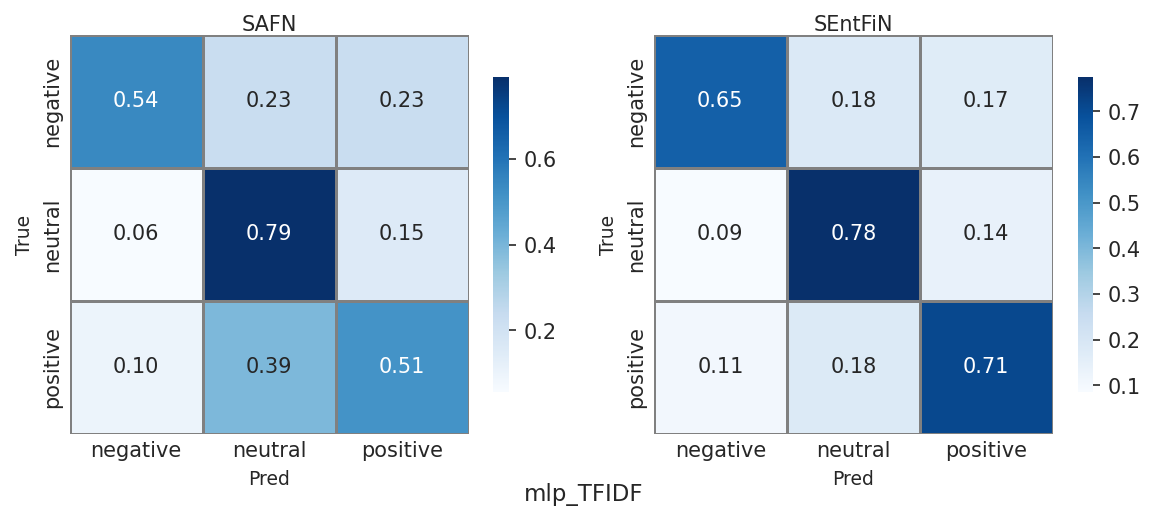


Plotting: bert


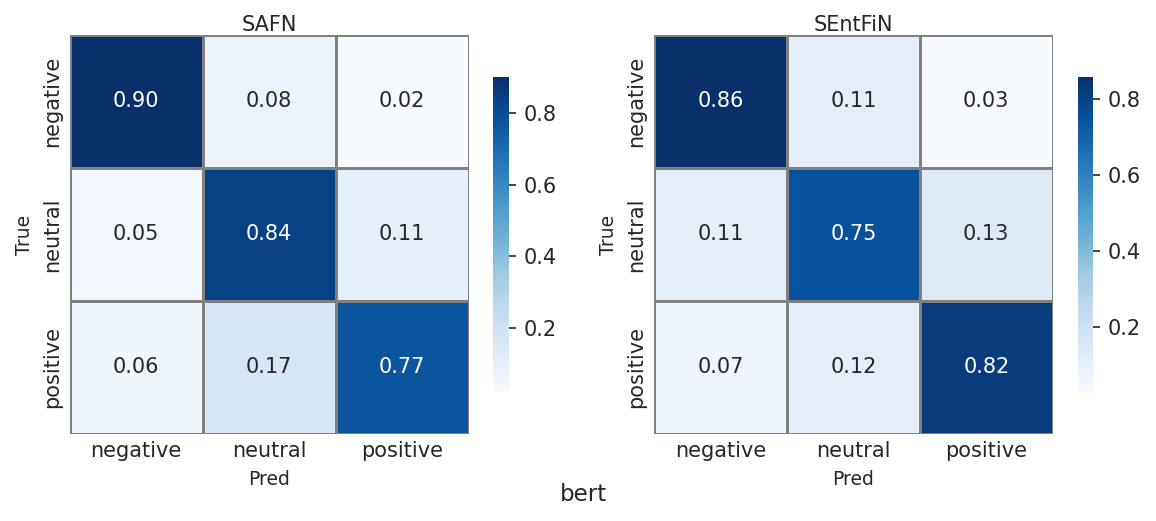


Plotting: textCNN


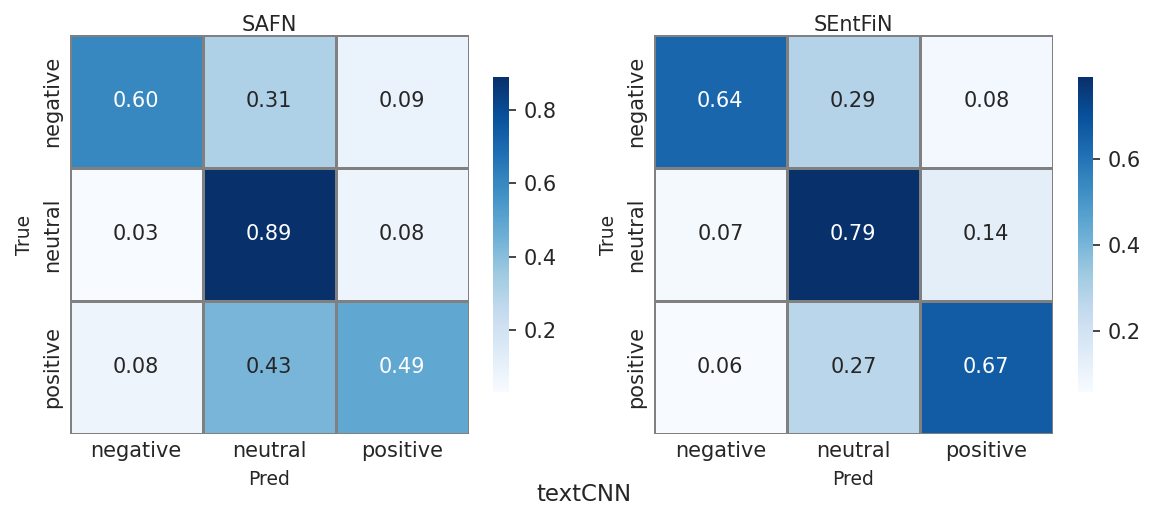


Plotting: RoBERTa


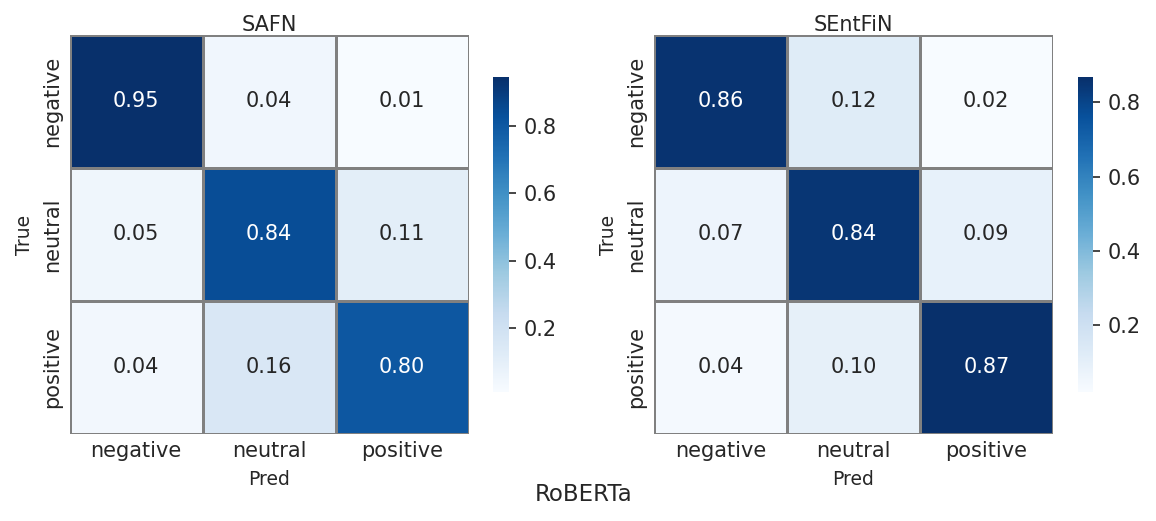


All confusion matrices plotted successfully.


In [18]:
# Configuration
data_paths = [
    '/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN/all_models_confusion_data.csv',
    '/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN/all_models_confusion_data.csv'
]

dataset_names = ['SAFN', 'SEntFiN']

# Label mapping
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Find all models
all_models = set()
for path in data_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        all_models.update(df['model'].unique())

print(f"Models found: {list(all_models)}")

# Plot for each model
for model in all_models:
    print(f"\nPlotting: {model}")
    fig = plot_model_confusion(model, data_paths, dataset_names, label_mapping)
    
    if fig is not None:
        save_path = f'/kaggle/working/{model}_confusion_matrices.png'
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)

print("\nAll confusion matrices plotted successfully.")